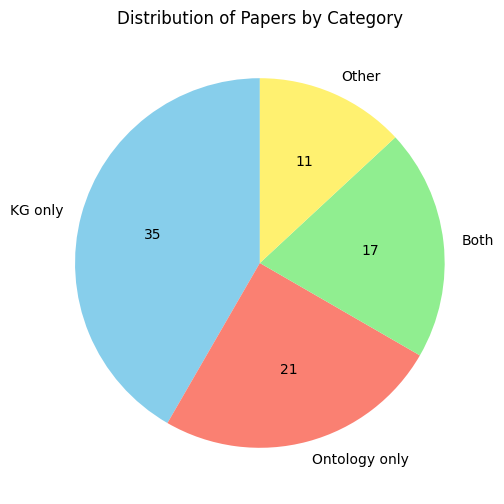

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel file
file_path = "SLR_summary.xlsx"  # update path if needed
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Count categories
counts = df["Category"].value_counts()

# Filter out "None"
plot_counts = counts.drop("None", errors="ignore")

# Plot bar chart
plt.figure(figsize=(6,6))
plot_counts.plot(
    kind="pie",
    autopct=lambda p: f'{int(round(p*sum(plot_counts)/100))}',   # show percentages
    startangle=90,       # rotate start
    colors=["skyblue", "salmon", "lightgreen","#FFF170"],
    ylabel=""            # remove default "Category"
)

plt.title("Distribution of Papers by Category")
plt.show()


C:\Users\20236193\AppData\Local\Temp\ipykernel_4196\2818402520.py:173: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(onto_s.index, rotation=45, ha="right")
C:\Users\20236193\AppData\Local\Temp\ipykernel_4196\2818402520.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(kg_s.index, rotation=45, ha="right")


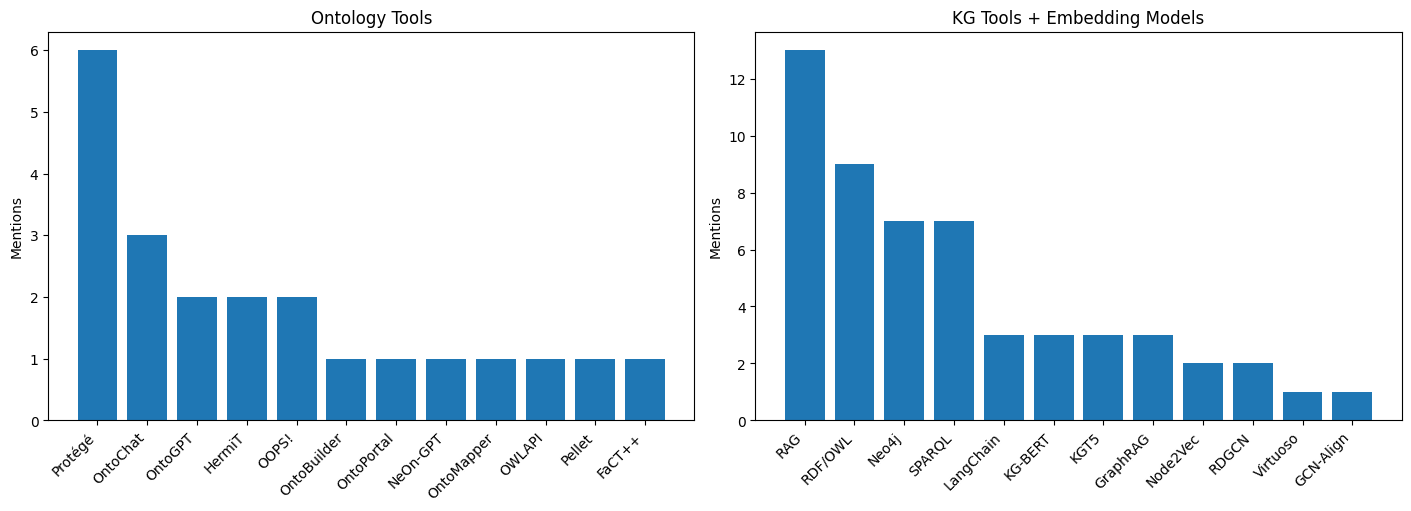

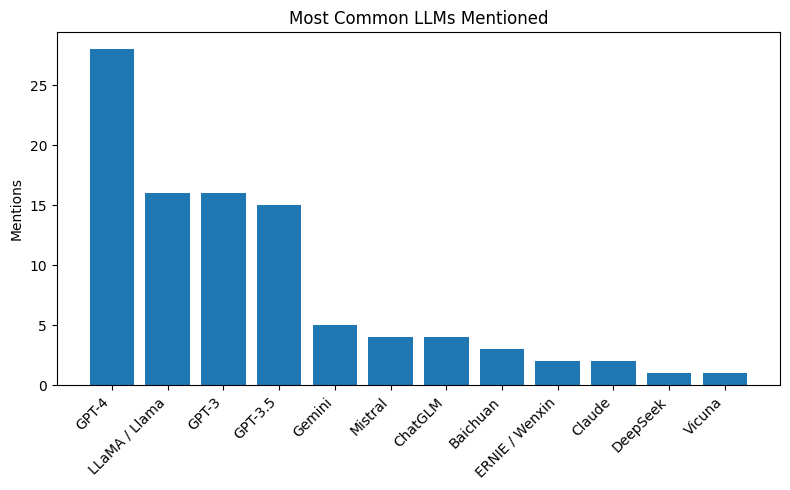


=== Ontology Tools Counts ===
Protégé        6
OntoChat       3
OntoGPT        2
HermiT         2
OOPS!          2
OntoBuilder    1
OntoPortal     1
NeOn-GPT       1
OntoMapper     1
OWLAPI         1
Pellet         1
FaCT++         1

=== KG Tools + Embeddings Counts ===
RAG          13
RDF/OWL       9
Neo4j         7
SPARQL        7
LangChain     3
KG-BERT       3
KGT5          3
GraphRAG      3
Node2Vec      2
RDGCN         2
Virtuoso      1
GCN-Align     1

=== LLM Counts ===
GPT-4             28
LLaMA / Llama     16
GPT-3             16
GPT-3.5           15
Gemini             5
Mistral            4
ChatGLM            4
Baichuan           3
ERNIE / Wenxin     2
Claude             2
DeepSeek           1
Vicuna             1


In [10]:
# -*- coding: utf-8 -*-
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# ----------------------------
# 1) Load data (Excel with CSV fallback)
# ----------------------------
FILE_XLSX = "SLR_summary.xlsx"
SHEET = "Sheet1"
CSV_FALLBACK = "SLR_summary.csv"

def load_df():
    try:
        # requires openpyxl
        df = pd.read_excel(FILE_XLSX, sheet_name=SHEET)
    except Exception:
        # fallback to CSV if Excel dependency is missing
        df = pd.read_csv(CSV_FALLBACK)
    return df

df = load_df()

if "RQ4: Tools/Platforms" not in df.columns:
    raise ValueError("Column 'RQ4: Tools/Platforms' not found. Please check the sheet headers.")

rq4_series = df["RQ4: Tools/Platforms"].fillna("").astype(str)

# ----------------------------
# 2) Canonical dictionaries (edit these to your needs)
#    - Each entry maps a canonical label -> list of regex snippets to match (case-insensitive)
#    - Patterns are OR-joined; we anchor smartly so 'Llama2' etc. are matched.
# ----------------------------

ONTOLOGY_TOOLS = {
    "Protégé":         [r"\bprot[eé]g[eé]\b"],
    "OOPS!":           [r"\boops!?(\b|$)"],
    "HermiT":          [r"\bhermit\b"],
    "FaCT++":          [r"\bfact\+\+\b"],
    "Pellet":          [r"\bpellet\b"],
    "OWLAPI":          [r"\bowl\s*api\b", r"\bowlapi\b"],
    "OntoPortal":      [r"\bonto\s*portal\b", r"\bontoportal\b"],
    "OntoGPT":         [r"\bonto\s*gpt\b", r"\bontogpt\b"],
    "OntoChat":        [r"\bonto\s*chat\b", r"\bontochat\b"],
    "NeOn-GPT":        [r"\bneon[-\s]*gpt\b"],
    "OntoGenix":       [r"\bontogenix\b"],
    "OntoBuilder":     [r"\bonto\s*builder\b", r"\bontobuilder\b"],
    "OntoMapper":      [r"\bonto\s*mapper\b", r"\bontomapper\b"],
    "OWL Reasoner":    [r"\bowl\s*reasoner(s)?\b"],
}

KG_TOOLS_AND_EMBEDDINGS = {
    # Graph/KG stores & tooling
    "Neo4j":           [r"\bneo4j\b"],
    "GraphDB":         [r"\bgraphdb\b"],
    "Stardog":         [r"\bstardog\b"],
    "Virtuoso":        [r"\bvirtuoso\b"],
    "RDFLib":          [r"\brdflib\b"],
    "SPARQL":          [r"\bsparql\b"],
    "RDF/OWL":         [r"\brdf\b", r"\bowl\b"],
    "LangChain":       [r"\blang\s*chain\b", r"\blangchain\b"],
    "LlamaIndex":      [r"\bllama\s*index\b", r"\bllamaindex\b"],
    "GraphRAG":        [r"\bgraph\s*rag\b", r"\bgraphrag\b"],
    # KG embedding/graph models
    "Node2Vec":        [r"\bnode2vec\b"],
    "TransE":          [r"\btranse\b"],
    "TransH":          [r"\btransh\b"],
    "TransR":          [r"\btransr\b"],
    "DistMult":        [r"\bdistmult\b"],
    "ComplEx":         [r"\bcomplex\b"],
    "RotatE":          [r"\brotate\b"],
    "HolE":            [r"\bhole\b"],
    "TuckER":          [r"\btucker\b"],
    "MTransE":         [r"\bmtranse\b"],
    "IPTransE":        [r"\biptranse\b"],
    "GCN-Align":       [r"\bgcn[-\s]*align\b"],
    "RDGCN":           [r"\brdgcn\b"],
    "AliNet":          [r"\balinet\b"],
    "MuGNN":           [r"\bmugnn\b"],
    "KG-BERT":         [r"\bkg[-\s]*bert\b"],
    "KGT5":            [r"\bkg\s*t5\b", r"\bkgt5\b"],
    # General but included as KG tooling if mentioned there
    "HuggingFace":     [r"\bhugging\s*face\b", r"\bhuggingface\b"],
    "RAG":             [r"\brag\b"],
}

LLMS = {
    # GPT family variants collapse into canonical labels
    "GPT-4":           [r"\bgpt[-\s]*4(o| turbo)?\b", r"\bchatgpt[-\s]*4\b"],
    "GPT-3.5":         [r"\bgpt[-\s]*3\.?5\b", r"\bgpt[-\s]*3\.?5[-\s]*turbo\b", r"\bchatgpt[-\s]*3\.?5\b"],
    "GPT-3":           [r"\bgpt[-\s]*3\b"],
    # Open models & others
    "LLaMA / Llama":   [r"\bllama[-\s]*2\b", r"\bllama[-\s]*3\b", r"\bllama\b", r"\bllama2\b", r"\bllama3\b", r"\bllama-?index\b(?!)"],
    "Mistral":         [r"\bmistral\b", r"\bmixtral\b"],
    "Gemini":          [r"\bgemini\b", r"\bmed[-\s]*gemini\b"],
    "Claude":          [r"\bclaude\b"],
    "Vicuna":          [r"\bvicuna\b"],
    "Baichuan":        [r"\bbaichuan\b"],
    "Qwen":            [r"\bqwen\b"],
    "DeepSeek":        [r"\bdeepseek\b"],
    "ERNIE / Wenxin":  [r"\bernie\b", r"\bwenxin\b"],
    "ChatGLM":         [r"\bchatglm\b"],
}

# Optional: exclude overly generic tokens that can cause false positives
EXCLUDE_TERMS = [
    r"\bexamples?\b", r"\bsubset\b", r"\bbaseline\b", r"\btemplate(s)?\b",
    r"\bdatabase(s)?\b", r"\bquality\b", r"\bguideline(s)?\b",
]

# ----------------------------
# 3) Helpers to count mentions
# ----------------------------
def compile_map(pattern_map):
    compiled = {}
    for canon, pats in pattern_map.items():
        compiled[canon] = [re.compile(p, flags=re.IGNORECASE) for p in pats]
    return compiled

EXCLUDE_PATS = [re.compile(p, re.IGNORECASE) for p in EXCLUDE_TERMS]
ONTO_PATS = compile_map(ONTOLOGY_TOOLS)
KG_PATS = compile_map(KG_TOOLS_AND_EMBEDDINGS)
LLM_PATS = compile_map(LLMS)

def is_excluded(text):
    return any(p.search(text) for p in EXCLUDE_PATS)

def count_matches(series, compiled_map):
    counter = Counter()
    for txt in series:
        if not txt:
            continue
        # Skip pure-noise strings
        if is_excluded(txt):
            # Note: we exclude at token-level later; here we only skip if the entire string is obviously noise.
            pass
        for canon, pats in compiled_map.items():
            if any(p.search(txt) for p in pats):
                counter[canon] += 1
    return counter

# ----------------------------
# 4) Count mentions
# ----------------------------
onto_counts = count_matches(rq4_series, ONTO_PATS)
kg_counts   = count_matches(rq4_series, KG_PATS)
llm_counts  = count_matches(rq4_series, LLM_PATS)

# Convert to Series for easier sorting/plotting
onto_s = pd.Series(onto_counts).sort_values(ascending=False)
kg_s   = pd.Series(kg_counts).sort_values(ascending=False)
llm_s  = pd.Series(llm_counts).sort_values(ascending=False)

# Optionally limit to top N for readability (set to None for all)
TOP_N = 12
if TOP_N:
    onto_s = onto_s.head(TOP_N)
    kg_s   = kg_s.head(TOP_N)
    llm_s  = llm_s.head(TOP_N)

# ----------------------------
# 5) Plotting
# ----------------------------

# Figure 1: Two subplots (Ontology tools, KG tools + Embeddings)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), constrained_layout=True)

# Ontology tools
axes[0].bar(onto_s.index, onto_s.values)
axes[0].set_title("Ontology Tools")
axes[0].set_ylabel("Mentions")
axes[0].set_xticklabels(onto_s.index, rotation=45, ha="right")

# KG tools + Embedding models
axes[1].bar(kg_s.index, kg_s.values)
axes[1].set_title("KG Tools + Embedding Models")
axes[1].set_ylabel("Mentions")
axes[1].set_xticklabels(kg_s.index, rotation=45, ha="right")

plt.show()

# Figure 2: LLMs (separate figure)
plt.figure(figsize=(8, 5))
plt.bar(llm_s.index, llm_s.values)
plt.title("Most Common LLMs Mentioned")
plt.ylabel("Mentions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------
# 6) (Optional) Print the raw counts for transparency
# ----------------------------
print("\n=== Ontology Tools Counts ===")
print(onto_s.to_string())
print("\n=== KG Tools + Embeddings Counts ===")
print(kg_s.to_string())
print("\n=== LLM Counts ===")
print(llm_s.to_string())





In [1]:
pip install collections

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections


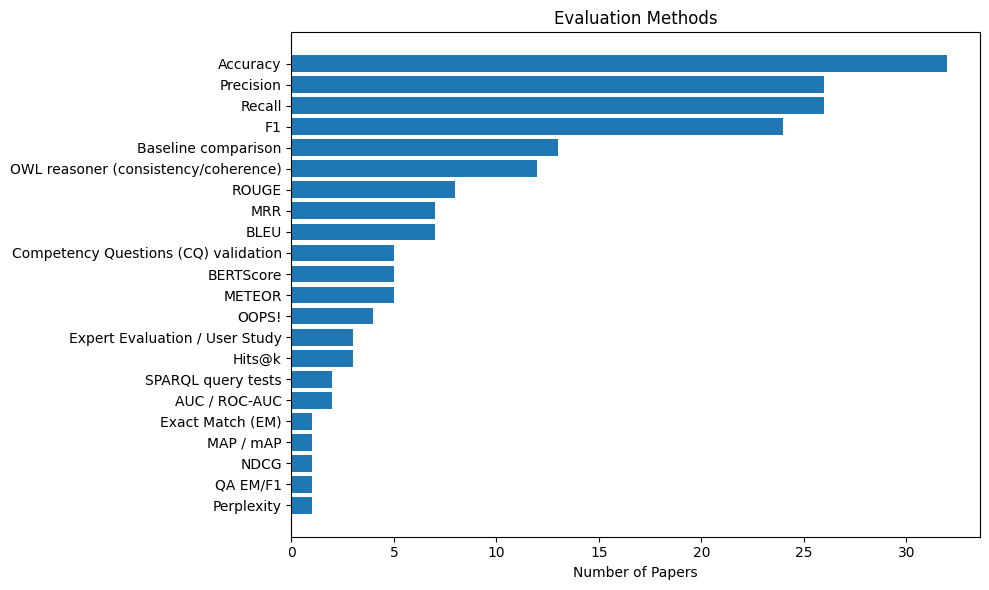

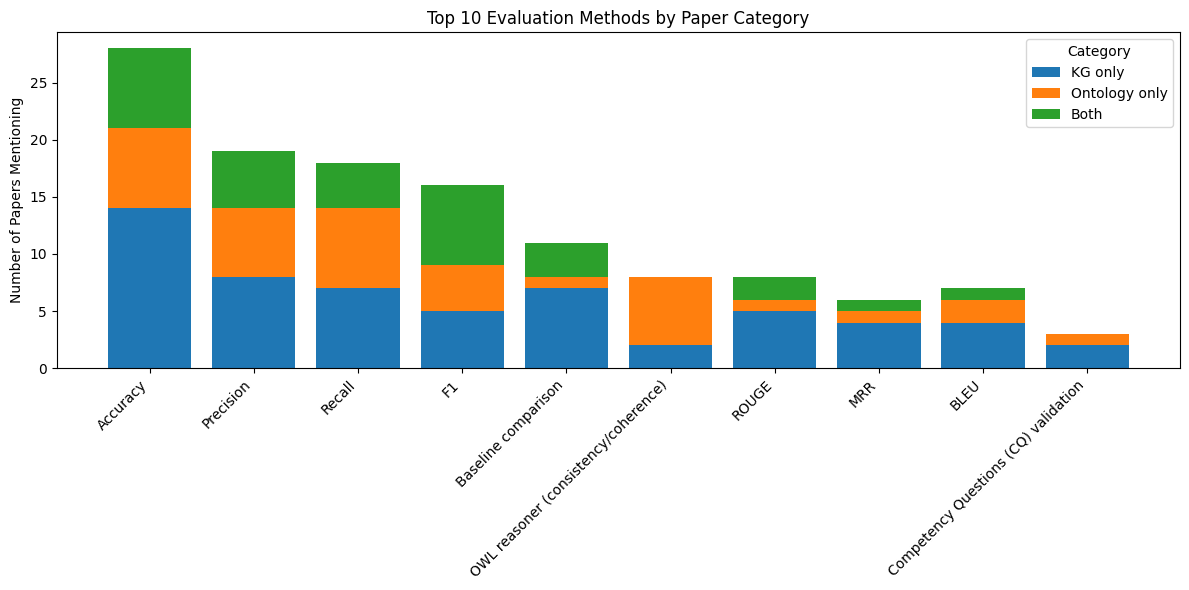


=== Overall Evaluation Methods (counts) ===
Accuracy: 32
Precision: 26
Recall: 26
F1: 24
Baseline comparison: 13
OWL reasoner (consistency/coherence): 12
ROUGE: 8
MRR: 7
BLEU: 7
Competency Questions (CQ) validation: 5
BERTScore: 5
METEOR: 5
OOPS!: 4
Expert Evaluation / User Study: 3
Hits@k: 3
SPARQL query tests: 2
AUC / ROC-AUC: 2
Exact Match (EM): 1
MAP / mAP: 1
NDCG: 1
QA EM/F1: 1
Perplexity: 1

=== Stacked counts (top methods by category) ===
                                      KG only  Ontology only  Both
Accuracy                                   14              7     7
Precision                                   8              6     5
Recall                                      7              7     4
F1                                          5              4     7
Baseline comparison                         7              1     3
OWL reasoner (consistency/coherence)        2              6     0
ROUGE                                       5              1     2
MRR          

In [9]:
# -*- coding: utf-8 -*-
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# ------------ Config ------------
FILE_XLSX = "SLR_summary.xlsx"     # Excel file name
SHEET = "Sheet1"                   # Sheet name
CSV_FALLBACK = "SLR_summary.csv"   # If openpyxl missing, save as CSV and use this
TOP_METHODS_FOR_STACK = 10       

# ------------ Load data (Excel with CSV fallback) ------------
def load_df():
    try:
        df = pd.read_excel(FILE_XLSX, sheet_name=SHEET)  # requires openpyxl
    except Exception:
        df = pd.read_csv(CSV_FALLBACK)
    return df

df = load_df()

# Check columns
need_cols = [
    "RQ1: Methods (Ontology/KG with LLMs)",
    "RQ5: Evaluation Metrics/Benchmarks",
]
for c in need_cols:
    if c not in df.columns:
        raise ValueError(f"Required column missing: {c}")

rq1_series = df["RQ1: Methods (Ontology/KG with LLMs)"].fillna("").astype(str)
rq5_series = df["RQ5: Evaluation Metrics/Benchmarks"].fillna("").astype(str)

# ------------ Classify papers into Category (KG only / Ontology only / Both) ------------
def classify_category(text):
    t = text.lower()
    has_kg = ("kg" in t) or ("knowledge graph" in t) or ("knowledge graphs" in t)
    has_onto = ("ontology" in t) or ("ontologies" in t) or ("ontological" in t)
    if has_kg and has_onto:
        return "Both"
    elif has_kg:
        return "KG only"
    elif has_onto:
        return "Ontology only"
    else:
        return "None"

df["Category"] = rq1_series.apply(classify_category)

# ------------ Evaluation method patterns ------------
patterns = {
    # Quantitative metrics
    "Accuracy": [r"\baccuracy\b", r"\bacc\b"],
    "Precision": [r"\bprecision\b"],
    "Recall": [r"\brecall\b"],
    "F1": [r"\bf-?1\b", r"\bmacro[-\s]?f1\b", r"\bmicro[-\s]?f1\b"],
    "Exact Match (EM)": [r"\bexact[\s-]*match\b", r"\b(?<![A-Z])EM(?![A-Z])\b"],
    "BLEU": [r"\bbleu\b"],
    "ROUGE": [r"\brouge\b"],
    "METEOR": [r"\bmeteor\b"],
    "BERTScore": [r"\bbert\s*score\b", r"\bbertscore\b"],
    "MRR": [r"\bmean reciprocal rank\b", r"\b(?<![A-Z])MRR(?![A-Z])\b"],
    "Mean Rank (MR)": [r"\bmean rank\b", r"\b(?<![A-Z])MR(?![A-Z])\b"],
    "Hits@k": [r"\bhits@?\s*\d+\b"],
    "MAP / mAP": [r"\bmean average precision\b", r"\b(?<![A-Z])m?AP(?![A-Z])\b"],
    "AUC / ROC-AUC": [r"\bauc\b", r"\broc-?auc\b", r"\barea under (the )?curve\b"],
    "NDCG": [r"\bndcg\b"],
    "Perplexity": [r"\bperplexity\b"],

    # Human/expert & agreement
    "Expert Evaluation / User Study": [
        r"\bexpert (evaluation|review|validation)\b",
        r"\buser (study|evaluation)\b",
        r"\bhuman evaluation\b",
        r"\bsurvey\b",
    ],
    "Inter-Annotator Agreement (IAA)": [
        r"\binter[-\s]?annotator (agreement|reliability)\b", r"\bIAA\b"
    ],
    "Cohen's Kappa": [r"\bcohen'?s?\s*kappa\b"],
    "Fleiss' Kappa": [r"\bfleiss'?s?\s*kappa\b"],

    # Ontology/KG quality methods & tools
    "OOPS!": [r"\boops!?(\b|$)"],
    "HermiT (reasoner)": [r"\bhermit\b"],
    "Pellet (reasoner)": [r"\bpellet\b"],
    "FaCT++ (reasoner)": [r"\bfact\+\+\b"],
    "OWL reasoner (consistency/coherence)": [
        r"\bowl\s*reasoner(s)?\b", r"\bconsisten(cy|t)\b", r"\bcoherence\b"
    ],
    "SHACL validation": [r"\bshacl\b"],
    "SPARQL query tests": [r"\bsparql\b"],
    "Competency Questions (CQ) validation": [
        r"\bcompetency questions?\b", r"\b(?<![A-Z])CQ(s)?(?![A-Z])\b"
    ],

    # Study/experimental setup
    "Baseline comparison": [r"\bbaseline(s)?\b"],

    # Task-specific QA shorthand
    "QA EM/F1": [r"\b(question answering|qa)\b.*\b(em|exact match|f-?1|f1)\b"],
}

compiled = {k: [re.compile(p, re.IGNORECASE) for p in v] for k, v in patterns.items()}

# ------------ Count mentions overall and per paper ------------
overall_counts = Counter()
paper_to_methods = defaultdict(set)

for idx, txt in rq5_series.items():
    for label, regexes in compiled.items():
        if any(r.search(txt) for r in regexes):
            overall_counts[label] += 1
            paper_to_methods[idx].add(label)

# Convert to sorted Series
overall_s = pd.Series(overall_counts).sort_values(ascending=False)

# ------------ Graph 1: Overall frequency (horizontal bar) ------------
plt.figure(figsize=(10, 6))
plt.barh(overall_s.index, overall_s.values)
plt.title("Evaluation Methods")
plt.xlabel("Number of Papers")
plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.show()

# ------------ Graph 2: Stacked bar by Category (KG only / Ontology only / Both) ------------
# Prepare a DataFrame: rows = methods (top N), cols = categories
categories = ["KG only", "Ontology only", "Both"]
top_methods = list(overall_s.head(TOP_METHODS_FOR_STACK).index)

stack_df = pd.DataFrame(0, index=top_methods, columns=categories, dtype=int)

for idx, methods in paper_to_methods.items():
    cat = df.loc[idx, "Category"]
    if cat not in categories:
        continue
    for m in methods:
        if m in stack_df.index:
            stack_df.loc[m, cat] += 1

# Plot stacked bars
plt.figure(figsize=(12, 6))
bottom = None
for i, cat in enumerate(categories):
    vals = stack_df[cat].values
    if i == 0:
        bars = plt.bar(stack_df.index, vals)
        bottom = vals
    else:
        bars = plt.bar(stack_df.index, vals, bottom=bottom)
        bottom = [b + v for b, v in zip(bottom, vals)]

plt.title(f"Top {len(top_methods)} Evaluation Methods by Paper Category")
plt.ylabel("Number of Papers Mentioning")
plt.xticks(rotation=45, ha="right")
plt.legend(categories, title="Category")
plt.tight_layout()
plt.show()

# ------------ (Optional) Print counts to console ------------
print("\n=== Overall Evaluation Methods (counts) ===")
for k, v in overall_s.items():
    print(f"{k}: {v}")

print("\n=== Stacked counts (top methods by category) ===")
print(stack_df)


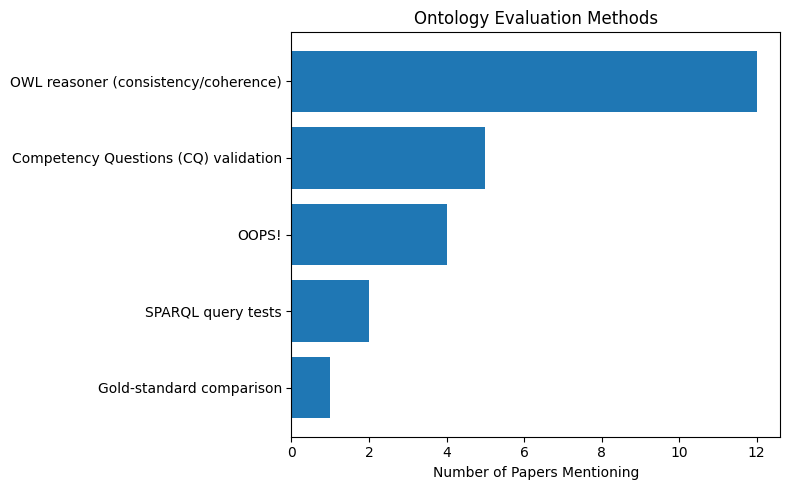

In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

FILE_XLSX = "SLR_summary.xlsx"
SHEET = "Sheet1"
CSV_FALLBACK = "SLR_summary.csv"

def load_df():
    try:
        return pd.read_excel(FILE_XLSX, sheet_name=SHEET)
    except Exception:
        return pd.read_csv(CSV_FALLBACK)

df = load_df()
rq5 = df["RQ5: Evaluation Metrics/Benchmarks"].fillna("").astype(str)

ONTOLOGY_EVAL_PATTERNS = {
    "OOPS!": [r"\boops!?(\b|$)"],
    "OWL reasoner (consistency/coherence)": [
        r"\bowl\s*reasoner(s)?\b", r"\bconsisten(cy|t)\b", r"\bcoherence\b"
    ],
    "HermiT": [r"\bhermit\b"],
    "Pellet": [r"\bpellet\b"],
    "FaCT++": [r"\bfact\+\+\b"],
    "SHACL validation": [r"\bshacl\b"],
    "SPARQL query tests": [r"\bsparql\b"],
    "Competency Questions (CQ) validation": [
        r"\bcompetency questions?\b", r"\b(?<![A-Z])CQ(s)?(?![A-Z])\b"
    ],
    "Gold-standard comparison": [r"\bgold[-\s]?standard\b"],
}

compiled = {k: [re.compile(p, re.IGNORECASE) for p in v] for k, v in ONTOLOGY_EVAL_PATTERNS.items()}

counts = Counter()
for txt in rq5:
    for label, regs in compiled.items():
        if any(r.search(txt) for r in regs):
            counts[label] += 1

s = pd.Series(counts).sort_values(ascending=True)

# Horizontal bar chart of ontology-only evaluation
plt.figure(figsize=(8, 5))
plt.barh(s.index, s.values)
plt.title("Ontology Evaluation Methods")
plt.xlabel("Number of Papers Mentioning")
plt.tight_layout()
plt.show()


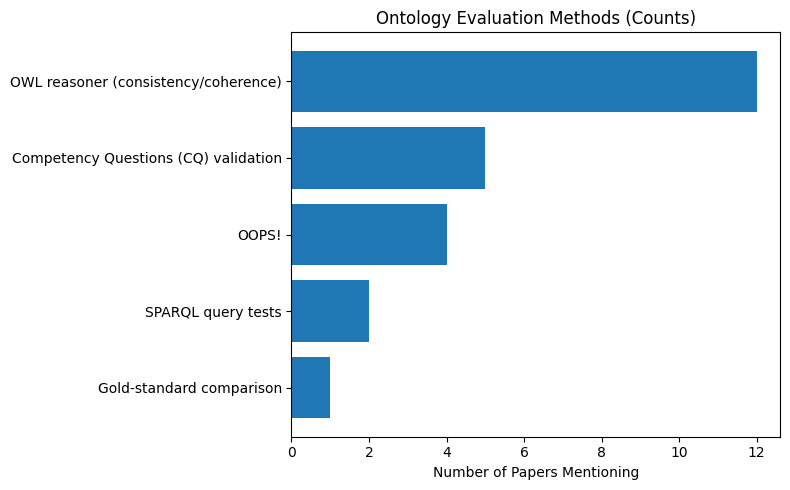

In [6]:

def load_df():
    try:
        return pd.read_excel(FILE_XLSX, sheet_name=SHEET)
    except Exception:
        return pd.read_csv(CSV_FALLBACK)

df = load_df()
rq5 = df["RQ5: Evaluation Metrics/Benchmarks"].fillna("").astype(str)

ONTOLOGY_EVAL_PATTERNS = {
    "OOPS!": [r"\boops!?(\b|$)"],
    "OWL reasoner (consistency/coherence)": [
        r"\bowl\s*reasoner(s)?\b", r"\bconsisten(cy|t)\b", r"\bcoherence\b"
    ],
    "HermiT": [r"\bhermit\b"],
    "Pellet": [r"\bpellet\b"],
    "FaCT++": [r"\bfact\+\+\b"],
    "SHACL validation": [r"\bshacl\b"],
    "SPARQL query tests": [r"\bsparql\b"],
    "Competency Questions (CQ) validation": [
        r"\bcompetency questions?\b", r"\b(?<![A-Z])CQ(s)?(?![A-Z])\b"
    ],
    "Gold-standard comparison": [r"\bgold[-\s]?standard\b"],
}

compiled = {k: [re.compile(p, re.IGNORECASE) for p in v] for k, v in ONTOLOGY_EVAL_PATTERNS.items()}

counts = Counter()
for txt in rq5:
    for label, regs in compiled.items():
        if any(r.search(txt) for r in regs):
            counts[label] += 1

s = pd.Series(counts).sort_values(ascending=True)

# Horizontal bar chart of ontology-only evaluation
plt.figure(figsize=(8, 5))
plt.barh(s.index, s.values)
plt.title("Ontology Evaluation Methods (Counts)")
plt.xlabel("Number of Papers Mentioning")
plt.tight_layout()
plt.show()


Frameworks (names + counts):
      Framework  Count
       OntoChat      3
           NeOn      3
       NeOn-GPT      2
        OntoGPT      2
      Ontogenia      2
       OntoGain      2
      Text2Onto      2
           OLAF      2
         SPIRES      1
      OntoGenix      1
          TANGO      1
           MOGO      1
       Populous      1
LOT methodology      1
      OntoCmaps      1
       DeepOnto      1
         DYNAMO      1
       OntoFact      1


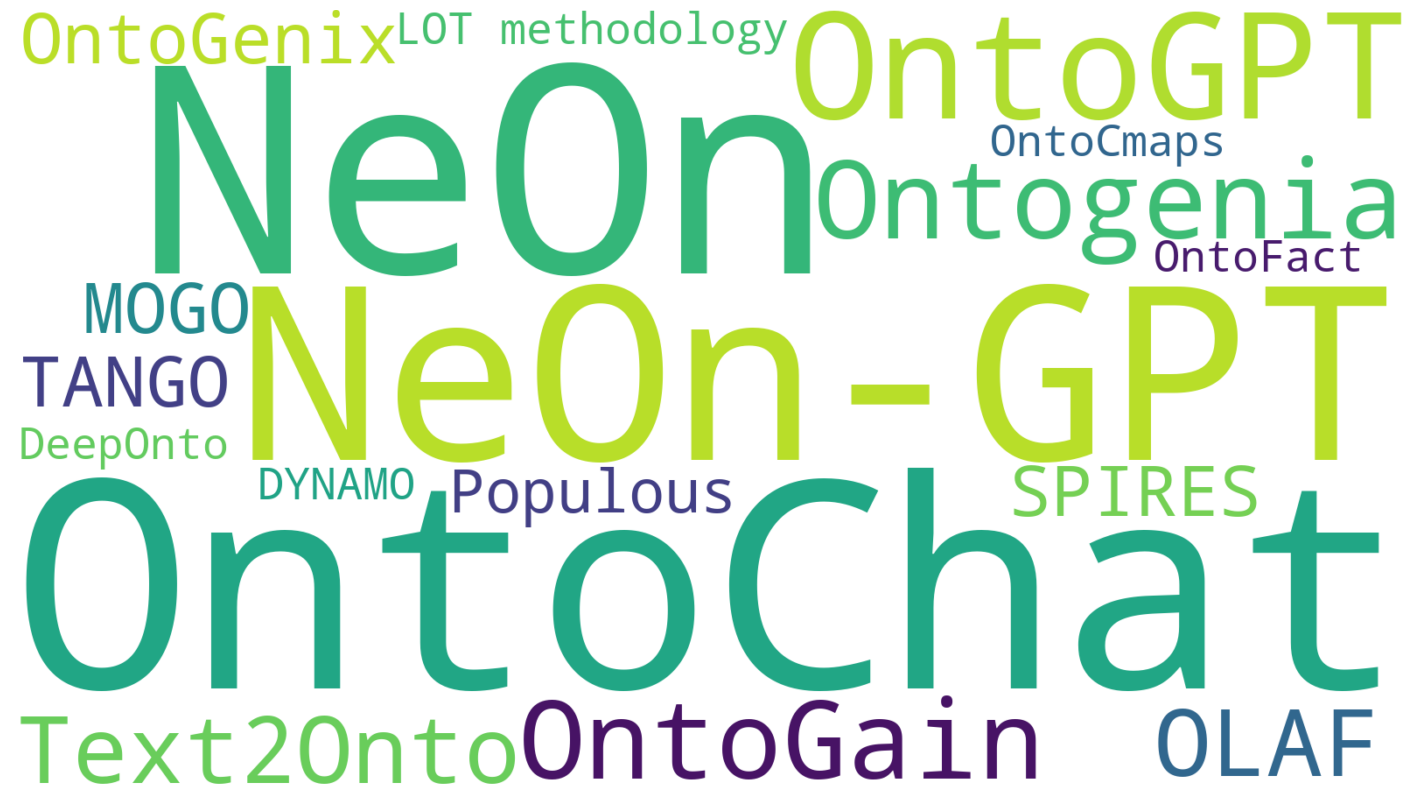


Saved word cloud to: ontology_frameworks_wordcloud.png
Saved names+counts to: ontology_framework_wordcloud_counts.csv


In [7]:
from collections import defaultdict
from wordcloud import WordCloud

# ---------------- Config ----------------
FILE_XLSX = "SLR_summary.xlsx"     # Excel file name
SHEET = "Sheet1"
CSV_FALLBACK = "SLR_summary.csv"   # CSV fallback (same columns as Excel)
USE_CSV = False                    # Set True to force CSV load
FORCE_OLAF_COUNT = 2               # <-- as requested
OUT_IMG = "ontology_frameworks_wordcloud.png"
OUT_CSV = "ontology_framework_wordcloud_counts.csv"

# ---------------- Load data ----------------
def load_df():
    if USE_CSV:
        return pd.read_csv(CSV_FALLBACK)
    try:
        return pd.read_excel(FILE_XLSX, sheet_name=SHEET)  # requires openpyxl
    except Exception:
        return pd.read_csv(CSV_FALLBACK)

df = load_df()

cols_to_scan = [
    "Paper title",
    "RQ1: Methods (Ontology/KG with LLMs)",
    "RQ3: Frameworks/Pipelines for Chatbots",
    "Key Contributions",
    "RQ2: Comparison with Traditional Approaches",
    "RQ4: Tools/Platforms",
]
missing = [c for c in cols_to_scan if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in the file: {missing}")

combined = df[cols_to_scan].fillna("").astype(str).agg(" ".join, axis=1)

# ---------------- Framework dictionary ----------------
# Expand/edit as needed. Patterns are case-insensitive regex.
framework_patterns = {
    "OLAF":              [r"\bOLAF\b"],
    "OntoGenix":         [r"\bOntoGenix\b"],
    "SPIRES":            [r"\bSPIRES\b"],
    "OntoGPT":           [r"\bOntoGPT\b"],
    "OntoChat":          [r"\bOntoChat\b"],
    "Ontogenia":         [r"\bOntogenia\b"],
    "OntoGain":          [r"\bOntoGain\b"],
    "DYNAMO":            [r"\bDYNAMO\b"],
    "DeepOnto":          [r"\bDeepOnto\b"],
    "Text2Onto":         [r"\bText2Onto\b"],
    "NeOn-GPT":          [r"\bNeOn-?GPT\b"],
    "LOT methodology":   [r"\bLOT(?:\s*-\s*methodology|\s+methodology)\b", r"\bLOT\b(?=\s+methodology)"],
    "NeOn":              [r"\bNeOn\b"],
    "TANGO":             [r"\bTANGO\b"],
    "MOGO":              [r"\bMOGO\b"],
    "Populous":          [r"\bPopulous\b"],
    "OntoCmaps":         [r"\bOntoCmaps?\b"],
    "OntoGen":           [r"\bOntoGen\b"],
    "OntoFact":          [r"\bOntoFact\b"],
}

compiled = {k: [re.compile(p, re.IGNORECASE) for p in v] for k, v in framework_patterns.items()}

# ---------------- Count mentions ----------------
counts = defaultdict(int)
for txt in combined:
    for label, regexes in compiled.items():
        if any(r.search(txt) for r in regexes):
            counts[label] += 1

# Force OLAF count to 2
counts["OLAF"] = max(counts.get("OLAF", 0), FORCE_OLAF_COUNT)

# Keep only non-zero counts and sort
counts_df = pd.DataFrame(
    sorted([(k, v) for k, v in counts.items() if v > 0], key=lambda x: x[1], reverse=True),
    columns=["Framework", "Count"]
)
print("Frameworks (names + counts):")
print(counts_df.to_string(index=False))
counts_df.to_csv(OUT_CSV, index=False)

# ---------------- Proper WordCloud ----------------
# Preserve multi-word labels by using non-breaking space in the keys
freqs = {name.replace(" ", "\u00A0"): int(cnt) for name, cnt in counts_df.values}

wc = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    prefer_horizontal=1.0,
    collocations=False,   # don't auto-merge words
    include_numbers=True,
).generate_from_frequencies(freqs)

plt.figure(figsize=(14, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# Save image
wc.to_file(OUT_IMG)
print(f"\nSaved word cloud to: {OUT_IMG}")
print(f"Saved names+counts to: {OUT_CSV}")


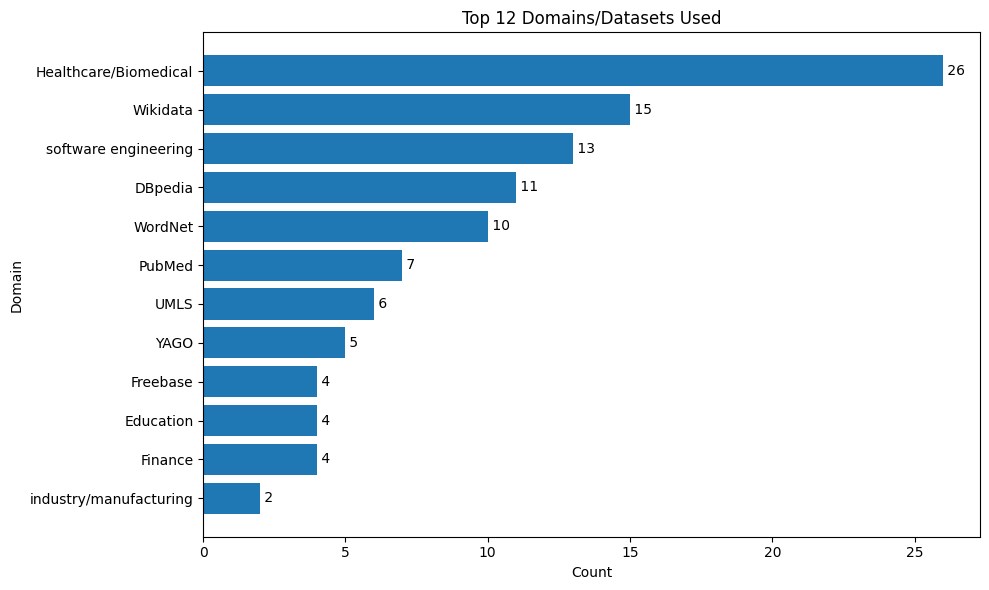

In [8]:
file_path = "Counts_of_Domain.csv"  # update path if needed
df = pd.read_csv(file_path)

col_name = None
for c in df.columns:
    if c.strip().lower() in {"domain/dataset", "domain_dataset", "domain", "dataset"}:
        col_name = c
        break
if col_name is None:
    raise ValueError("Couldn't find a 'Domain/Dataset' column in the CSV.")

count_col = None
for c in df.columns:
    if c.strip().lower() in {"count", "counts", "frequency", "freq"}:
        count_col = c
        break
if count_col is None:
    raise ValueError("Couldn't find a 'Count' column in the CSV.")

# Make sure Count is numeric
df[count_col] = pd.to_numeric(df[count_col], errors="coerce").fillna(0).astype(int)

# Sort by count desc
df_sorted = df.sort_values(count_col, ascending=False)

# Limit to top N (optional)
plot_df = df_sorted if TOP_N is None else df_sorted.head(TOP_N)

# --- Plot ---
plt.figure(figsize=(10, max(6, 0.4 * len(plot_df))))
# Reverse order so largest is at the top
y_labels = plot_df[col_name].iloc[::-1]
y_vals   = plot_df[count_col].iloc[::-1]

plt.barh(y_labels, y_vals)
plt.title(f"Top {len(plot_df)} Domains/Datasets Used")
plt.xlabel("Count")
plt.ylabel("Domain")

# Add value labels
for i, v in enumerate(y_vals):
    plt.text(v, i, f" {int(v)}", va="center")

plt.tight_layout()
plt.show()

